# 09 · Realistic Forecasting：未来真实天气的 Oracle Gap

## tl;dr

在与 08 严格相同的 60 个日频起点上，移除未来真实天气后，24h 的 Recursive/Direct MAE 分别增加 **1,084 / 821 rides/hour**；168h 分别增加 **2,366 / 1,007 rides/hour**。72h、168h 的策略排名由 Oracle 下 Recursive 较好，转为无未来天气时 Direct 较好。短 horizon 的差距并非单调，3h/6h 部分 Gap 为负。末尾的 Final Findings 说明高峰差异及部署限制。

## Context & Methods · 保持 08 的比较口径

- **主 benchmark：**每个 horizon 使用 07/08 相同的 60 个日频首个未来小时；目标是首个未来小时起第 h 小时，评价的是恰好提前 h 小时的 60 个点，不是未来 1 到 h 小时的整体误差。
- **Forecast origin：**定义为首个未来小时之前的最后一个已结束小时。假设该小时需求已经结算，故需求历史可用至 origin（含）；标签目标严格在 origin 之后。若上线时结算有延迟，需要额外后移所有需求特征。
- **唯一实验变量：**Oracle 输入目标时刻四项真实天气；Realistic 输入同样的目标日历和同样的起点前需求状态，但完全不含未来天气。训练配对、参数和目标点均相同。
- **高峰辅助样本：**复用 08 的 2024-11-18 至 12-15 的 672 个共同目标小时，对 24/72/168h 分别移动起报时间。它与主表的 60 点口径分开报告。

### Key Assumptions

实际预测于 origin 小时结束后发出；目标日历可以预先确定。训练用历史已发生的天气不是这里的泄漏问题，但为了只改变一个变量，Realistic 模型完全剔除天气。未来天气预报若可获得，线上性能可能介于无未来天气与 Oracle 之间；这不是本次实验实测的第三种模型。

## Data · 复用 07/08 的时间序列与固定切分

先在完整连续小时上计算需求滞后特征，再删去 07/08 排除的两个 DST 特殊建模行。这样 lag 的小时含义与旧实验一致。数据源只读：data/processed/bikeflow_2024.csv。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

HORIZONS = (1, 3, 6, 12, 24, 48, 72, 168)
PEAK_HORIZONS = (24, 72, 168)
WEATHER_COLUMNS = [
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m",
]
DEMAND_COLUMNS = ["lag_1", "lag_24", "lag_168", "rolling_mean_3", "rolling_mean_6"]
MODEL_PARAMETERS = {
    "max_iter": 240, "learning_rate": 0.07, "max_leaf_nodes": 31,
    "min_samples_leaf": 25, "l2_regularization": 0.1,
    "early_stopping": False, "random_state": 42,
}
COLORS = {
    "Recursive Oracle": "#24567A",
    "Recursive Realistic": "#55A1B3",
    "Direct Oracle": "#B05A42",
    "Direct Realistic": "#E2A469",
    "Weekly Naive": "#77765A",
}
plt.rcParams.update({
    "figure.figsize": (11, 5), "font.size": 10,
    "axes.grid": False, "savefig.dpi": 130,
})

project_root = Path.cwd()
if not (project_root / "data" / "processed" / "bikeflow_2024.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "processed" / "bikeflow_2024.csv"
assert data_path.exists(), f"未找到数据：{data_path}"

data = pd.read_csv(data_path, parse_dates=["timestamp"])
data = data.sort_values("timestamp").reset_index(drop=True)
spring_gap = pd.Timestamp("2024-03-10 02:00")
fall_repeat = pd.Timestamp("2024-11-03 01:00")
assert len(data) == 8784
assert data["timestamp"].is_unique
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()
raw_weather_columns = set(data.columns) - {"timestamp", "ride_count"}

for lag in (1, 24, 168):
    data[f"lag_{lag}"] = data["ride_count"].shift(lag)
prior_demand = data["ride_count"].shift(1)
for window in (3, 6):
    data[f"rolling_mean_{window}"] = prior_demand.rolling(
        window=window, min_periods=window
    ).mean()

normal_hour_mask = ~data["timestamp"].isin([spring_gap, fall_repeat])
model_data = data.loc[normal_hour_mask].copy().reset_index(drop=True)
split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data.loc[split_index, "timestamp"]
test_end = model_data["timestamp"].iloc[-1]
assert len(model_data) == 8782 and split_index == 7025
assert fixed_test_start == pd.Timestamp("2024-10-19 18:00")
assert test_end == pd.Timestamp("2024-12-31 23:00")

observed_demand = data.set_index("timestamp")["ride_count"]
valid_history = model_data[DEMAND_COLUMNS].notna().all(axis=1)
print(f"来源：{data_path}")
print(f"完整小时 {len(data):,}；建模小时 {len(model_data):,}")
print(f"固定测试期：{fixed_test_start} 至 {test_end}")

来源：C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
完整小时 8,784；建模小时 8,782
固定测试期：2024-10-19 18:00:00 至 2024-12-31 23:00:00


## Features · Oracle 与 Realistic 的信息边界

**oracle_features = 38 个目标日历 dummy + 4 项目标时刻真实天气 + 5 项需求历史。** 四项天气是 temperature_2m、relative_humidity_2m、precipitation、wind_speed_10m；在起报时尚未真实发生，因此属于 Oracle 信息。原始 CSV 的其他天气列（体感温度、雨、雪、天气代码）在 07/08 本来就没有进入模型。

**realistic_features = 相同 38 个目标日历 dummy + 相同 5 项需求历史。** hour、day_of_week、month 可从未来时间戳确定；is_weekend 也可确定，但与 day_of_week 重复，沿用 08 的做法只供审计、不新增入模列。Direct 的需求特征固定为首个未来小时之前的历史状态；Recursive 在后续步只用起点前已观测需求或自己先前预测的需求，绝不读取目标期真实需求。

In [2]:
target_calendar = pd.DataFrame({
    "target_hour": pd.Categorical(
        model_data["timestamp"].dt.hour, categories=range(24)
    ),
    "target_day_of_week": pd.Categorical(
        model_data["timestamp"].dt.dayofweek, categories=range(7)
    ),
    "target_month": pd.Categorical(
        model_data["timestamp"].dt.month, categories=range(1, 13)
    ),
    "target_is_weekend": model_data["timestamp"].dt.dayofweek.ge(5).astype(int),
})
calendar_dummies_all = pd.get_dummies(
    target_calendar[["target_hour", "target_day_of_week", "target_month"]],
    drop_first=True, dtype=int,
)
training_calendar_mask = model_data["timestamp"] < fixed_test_start
calendar_columns = calendar_dummies_all.loc[
    training_calendar_mask
].columns[calendar_dummies_all.loc[training_calendar_mask].any(axis=0)].tolist()
assert len(calendar_columns) == 38

calendar_target = calendar_dummies_all[calendar_columns].copy()
calendar_target.index = pd.DatetimeIndex(model_data["timestamp"])
weather_target = model_data[WEATHER_COLUMNS].copy()
weather_target.index = calendar_target.index
oracle_target_exogenous = pd.concat([calendar_target, weather_target], axis=1)
realistic_target_exogenous = calendar_target.copy()
scenario_exogenous = {
    "oracle": oracle_target_exogenous,
    "realistic": realistic_target_exogenous,
}

origin_demand = model_data[DEMAND_COLUMNS].copy()
origin_demand.index = calendar_target.index
oracle_features = calendar_columns + WEATHER_COLUMNS + DEMAND_COLUMNS
realistic_features = calendar_columns + DEMAND_COLUMNS
scenario_features = {"oracle": oracle_features, "realistic": realistic_features}
assert len(oracle_features) == 47 and len(realistic_features) == 43
assert set(realistic_features).isdisjoint(raw_weather_columns)
assert set(realistic_target_exogenous.columns).isdisjoint(raw_weather_columns)
assert oracle_target_exogenous.notna().all(axis=None)
assert realistic_target_exogenous.notna().all(axis=None)
assert calendar_target.index.is_unique and origin_demand.index.is_unique

display(pd.DataFrame([
    {"Scenario": "Oracle", "Calendar": 38, "Future actual weather": 4,
     "Origin demand": 5, "Total features": len(oracle_features)},
    {"Scenario": "Realistic", "Calendar": 38, "Future actual weather": 0,
     "Origin demand": 5, "Total features": len(realistic_features)},
]))

,Scenario,Calendar,Future actual weather,Origin demand,Total features
0,Oracle,38,4,5,47
1,Realistic,38,0,5,43


## Training pairs · Direct 标签固定在 t+h

沿用 08 的 Direct 设计：一条样本由首个未来小时 first_future、目标小时 target=first_future+(h−1) 小时组成。目标日历（及 Oracle 天气）取 target；五项需求状态始终取 first_future 的 lag/rolling 行，其原始需求来源全部不晚于 forecast origin。训练标签必须严格早于固定测试起点，以免跨界训练。

In [3]:
def make_direct_matrix(scenario, first_future_times, target_times):
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    assert len(first_future_times) == len(target_times)
    assert (target_times >= first_future_times).all()
    target_part = scenario_exogenous[scenario].loc[
        target_times
    ].reset_index(drop=True)
    history_part = origin_demand.loc[
        first_future_times, DEMAND_COLUMNS
    ].reset_index(drop=True)
    matrix = pd.concat([target_part, history_part], axis=1)[scenario_features[scenario]]
    assert matrix.notna().all(axis=None)
    assert np.isfinite(matrix.to_numpy()).all()
    return matrix


first_future_candidates = pd.DatetimeIndex(
    model_data.loc[valid_history, "timestamp"]
)
training_specs = {}
expected_training_counts = (6857, 6854, 6851, 6845, 6833, 6809, 6785, 6689)
for horizon, expected_count in zip(HORIZONS, expected_training_counts):
    target_times = first_future_candidates + pd.Timedelta(hours=horizon - 1)
    use = (
        target_times.isin(calendar_target.index)
        & (target_times < fixed_test_start)
        & (first_future_candidates < fixed_test_start)
    )
    train_first_future = first_future_candidates[use]
    train_targets = target_times[use]
    assert len(train_targets) == expected_count
    training_specs[horizon] = (train_first_future, train_targets)

test_valid_times = set(model_data.loc[
    (model_data["timestamp"] >= fixed_test_start) & valid_history,
    "timestamp",
])
candidate_07_origins = pd.date_range(
    fixed_test_start, test_end - pd.Timedelta(hours=167), freq="24h"
)
first_future_origins_07 = pd.DatetimeIndex([
    origin for origin in candidate_07_origins
    if all(
        target in test_valid_times
        for target in pd.date_range(origin, periods=168, freq="h")
    )
])
assert len(candidate_07_origins) == 67 and len(first_future_origins_07) == 60

peak_target_times = pd.date_range(
    "2024-11-18 00:00", "2024-12-15 23:00", freq="h"
)
assert len(peak_target_times) == 672
assert peak_target_times.isin(calendar_target.index).all()
assert peak_target_times.min() - pd.Timedelta(hours=167) >= fixed_test_start
print("主评估：60 个起点 × 8 个 horizon；高峰辅助评估：672 个共同目标小时。")

主评估：60 个起点 × 8 个 horizon；高峰辅助评估：672 个共同目标小时。


## Checks · 全样本 Leakage Audit

这一格逐 horizon 检查**所有训练配对**、60 个主评估配对，以及高峰分析的 672 个辅助配对。Demand lag/rolling 的真实来源均在 first_future 之前，即不晚于最后已观测小时 forecast origin；Direct 标签精确等于 t+h。Realistic 的列白名单与原始八个天气字段不相交。递归预测还会在模型训练后做一次反事实检查：任意篡改某个起点之后的真实需求，预测轨迹必须逐点不变。

In [4]:
def audit_pairs(first_future_times, target_times, horizon, *, training):
    first_future_times = pd.DatetimeIndex(first_future_times)
    target_times = pd.DatetimeIndex(target_times)
    origins = first_future_times - pd.Timedelta(hours=1)
    assert len(first_future_times) == len(target_times)
    assert (target_times == first_future_times + pd.Timedelta(hours=horizon - 1)).all()
    assert (target_times > origins).all()
    if training:
        assert (target_times < fixed_test_start).all()
        assert (first_future_times < fixed_test_start).all()
    else:
        assert (first_future_times >= fixed_test_start).all()
        assert (target_times <= test_end).all()

    for lag in (1, 24, 168):
        source = first_future_times - pd.Timedelta(hours=lag)
        assert (source <= origins).all()
        expected = observed_demand.reindex(source).to_numpy()
        actual_feature = origin_demand.loc[
            first_future_times, f"lag_{lag}"
        ].to_numpy()
        assert np.isfinite(expected).all()
        assert np.allclose(actual_feature, expected)
    for window in (3, 6):
        sources = [
            first_future_times - pd.Timedelta(hours=back)
            for back in range(1, window + 1)
        ]
        assert all((source <= origins).all() for source in sources)
        expected = np.mean(
            np.column_stack([
                observed_demand.reindex(source).to_numpy()
                for source in sources
            ]),
            axis=1,
        )
        actual_feature = origin_demand.loc[
            first_future_times, f"rolling_mean_{window}"
        ].to_numpy()
        assert np.allclose(actual_feature, expected)

    # 同一批起点和目标分别生成两种模型矩阵；两者无缺失且需求列逐点相同。
    oracle_matrix = make_direct_matrix(
        "oracle", first_future_times, target_times
    )
    realistic_matrix = make_direct_matrix(
        "realistic", first_future_times, target_times
    )
    assert set(realistic_matrix.columns).isdisjoint(raw_weather_columns)
    assert np.array_equal(
        oracle_matrix[realistic_features].to_numpy(),
        realistic_matrix.to_numpy(),
    )
    labels = observed_demand.reindex(target_times).to_numpy()
    assert np.isfinite(labels).all()
    return len(labels)


audit_rows = []
for horizon in HORIZONS:
    train_first, train_target = training_specs[horizon]
    main_first = first_future_origins_07
    main_target = main_first + pd.Timedelta(hours=horizon - 1)
    train_count = audit_pairs(train_first, train_target, horizon, training=True)
    main_count = audit_pairs(main_first, main_target, horizon, training=False)
    peak_count = 0
    if horizon in PEAK_HORIZONS:
        peak_first = peak_target_times - pd.Timedelta(hours=horizon - 1)
        peak_count = audit_pairs(
            peak_first, peak_target_times, horizon, training=False
        )
    assert main_count == 60
    audit_rows.append({
        "Horizon": horizon,
        "Training pairs checked": train_count,
        "Main test pairs checked": main_count,
        "Peak sample pairs checked": peak_count,
        "Lag/rolling observed sources <= origin": "PASS",
        "Realistic future actuals excluded": "PASS",
        "Direct label = t+h": "PASS",
    })
audit_table = pd.DataFrame(audit_rows)
display(audit_table)

,Horizon,Training pairs checked,Main test pairs checked,Peak sample pairs checked,Lag/rolling observed sources <= origin,Realistic future actuals excluded,Direct label = t+h
0,1,6857,60,0,PASS,PASS,PASS
1,3,6854,60,0,PASS,PASS,PASS
2,6,6851,60,0,PASS,PASS,PASS
3,12,6845,60,0,PASS,PASS,PASS
4,24,6833,60,672,PASS,PASS,PASS
5,48,6809,60,0,PASS,PASS,PASS
6,72,6785,60,672,PASS,PASS,PASS
7,168,6689,60,672,PASS,PASS,PASS


## Models · 相同 HGB 参数，无调参

每个 scenario 各训练八个 Direct HGB；h=1 的模型也用作 Recursive 的 one-step 模型。两边使用完全相同的训练配对与固定 random_state=42，避免把调参差异误认为天气作用。

In [5]:
models = {"oracle": {}, "realistic": {}}
for scenario in ("oracle", "realistic"):
    for horizon in HORIZONS:
        train_first, train_target = training_specs[horizon]
        matrix = make_direct_matrix(scenario, train_first, train_target)
        label = observed_demand.reindex(train_target).to_numpy()
        fitted = HistGradientBoostingRegressor(**MODEL_PARAMETERS)
        fitted.fit(matrix, label)
        models[scenario][horizon] = fitted
    print(f"{scenario}: 已训练 {len(models[scenario])} 个 HGB；h=1 复用于 Recursive")
assert all(len(models[scenario]) == 8 for scenario in models)

oracle: 已训练 8 个 HGB；h=1 复用于 Recursive


realistic: 已训练 8 个 HGB；h=1 复用于 Recursive


## Recursive · 每条轨迹只读已知需求或自身预测

对一批起点逐步推进，但每个起点都持有自己的预测历史。若某个 lag/rolling 的源时刻不晚于该起点的 origin，就取已观察需求；否则只能取同一轨迹先前的预测值。天气只由所选 scenario 的目标特征表决定。

In [6]:
def recursive_predict(first_future_times, horizon, scenario, history=observed_demand):
    starts = pd.DatetimeIndex(first_future_times)
    origins = starts - pd.Timedelta(hours=1)
    predictions = np.full((len(starts), horizon), np.nan)
    exogenous = scenario_exogenous[scenario]
    feature_columns = scenario_features[scenario]
    one_step_model = models[scenario][1]

    for step in range(1, horizon + 1):
        target_times = starts + pd.Timedelta(hours=step - 1)
        row = exogenous.loc[target_times].reset_index(drop=True).copy()
        for lag in (1, 24, 168):
            if step <= lag:
                source_times = target_times - pd.Timedelta(hours=lag)
                assert (source_times <= origins).all()
                values = history.reindex(source_times).to_numpy()
            else:
                values = predictions[:, step - lag - 1]
            row[f"lag_{lag}"] = values
        for window in (3, 6):
            components = []
            for back in range(1, window + 1):
                if step <= back:
                    source_times = target_times - pd.Timedelta(hours=back)
                    assert (source_times <= origins).all()
                    components.append(history.reindex(source_times).to_numpy())
                else:
                    components.append(predictions[:, step - back - 1])
            row[f"rolling_mean_{window}"] = np.mean(
                np.column_stack(components), axis=1
            )
        matrix = row[feature_columns]
        assert matrix.notna().all(axis=None)
        predictions[:, step - 1] = one_step_model.predict(matrix)
    assert np.isfinite(predictions).all()
    return predictions


# 反事实：一个起点之后的真实需求即使被巨幅篡改，两种递归轨迹也不得改变。
audit_first_future = first_future_origins_07[0]
future_corrupted_history = observed_demand.copy()
future_corrupted_history.loc[
    future_corrupted_history.index >= audit_first_future
] += 1_000_000
counterfactual_rows = []
for scenario in ("oracle", "realistic"):
    baseline = recursive_predict(
        [audit_first_future], 168, scenario, observed_demand
    )
    counterfactual = recursive_predict(
        [audit_first_future], 168, scenario, future_corrupted_history
    )
    maximum_change = float(np.max(np.abs(baseline - counterfactual)))
    assert maximum_change == 0.0
    counterfactual_rows.append({
        "Scenario": scenario,
        "Future actual demand perturbation": "+1,000,000 rides",
        "Max prediction change": maximum_change,
        "Result": "PASS",
    })
display(pd.DataFrame(counterfactual_rows))

,Scenario,Future actual demand perturbation,Max prediction change,Result
0,oracle,"+1,000,000 rides",0.0,PASS
1,realistic,"+1,000,000 rides",0.0,PASS


## Results · 60 个严格配对的目标点

下表的每一行对应同一个 horizon、同一批 first_future/target 配对。Oracle 与 Realistic 的 Recursive、Direct，以及 Weekly Seasonal Naive 全部在这些点上评分；没有因缺失值而改变评价区间。Mean Error 定义为 Actual − Prediction，正数表示平均低估。

In [7]:
recursive_grid = {
    scenario: recursive_predict(first_future_origins_07, 168, scenario)
    for scenario in ("oracle", "realistic")
}
main_parts = []
for horizon in HORIZONS:
    target_times = first_future_origins_07 + pd.Timedelta(hours=horizon - 1)
    actual = observed_demand.reindex(target_times).to_numpy()
    weekly_sources = target_times - pd.Timedelta(hours=168)
    assert (weekly_sources <= first_future_origins_07 - pd.Timedelta(hours=1)).all()
    weekly = observed_demand.reindex(weekly_sources).to_numpy()
    row = {
        "Horizon": horizon,
        "First Future Hour": first_future_origins_07,
        "Forecast Origin": first_future_origins_07 - pd.Timedelta(hours=1),
        "Target Timestamp": target_times,
        "Actual": actual,
        "Weekly Naive": weekly,
    }
    for scenario in ("oracle", "realistic"):
        label = scenario.title()
        row[f"Recursive {label}"] = recursive_grid[scenario][:, horizon - 1]
        row[f"Direct {label}"] = models[scenario][horizon].predict(
            make_direct_matrix(scenario, first_future_origins_07, target_times)
        )
    main_parts.append(pd.DataFrame(row))
main_panel = pd.concat(main_parts, ignore_index=True)
main_keys = ["Horizon", "First Future Hour", "Target Timestamp"]
assert len(main_panel) == 60 * len(HORIZONS)
assert not main_panel.duplicated(main_keys).any()
assert main_panel.groupby("Horizon").size().eq(60).all()
prediction_columns = [
    "Recursive Oracle", "Recursive Realistic",
    "Direct Oracle", "Direct Realistic", "Weekly Naive",
]
assert np.isfinite(main_panel[["Actual"] + prediction_columns].to_numpy()).all()
assert np.allclose(
    main_panel.loc[main_panel["Horizon"].eq(1), "Recursive Oracle"],
    main_panel.loc[main_panel["Horizon"].eq(1), "Direct Oracle"],
    atol=1e-9,
)
assert np.allclose(
    main_panel.loc[main_panel["Horizon"].eq(1), "Recursive Realistic"],
    main_panel.loc[main_panel["Horizon"].eq(1), "Direct Realistic"],
    atol=1e-9,
)
print(f"严格配对：{len(main_panel)} 行，8 个 horizon 各 60 点；五种预测均无缺失。")
display(main_panel.head(4))

严格配对：480 行，8 个 horizon 各 60 点；五种预测均无缺失。


,Horizon,First Future Hour,Forecast Origin,Target Timestamp,Actual,Weekly Naive,Recursive Oracle,Direct Oracle,Recursive Realistic,Direct Realistic
0,1,2024-10-19 18:00:00,2024-10-19 17:00:00,2024-10-19 18:00:00,11471,11670,11571.081670,11571.081670,11737.436627,11737.436627
1,1,2024-10-20 18:00:00,2024-10-20 17:00:00,2024-10-20 18:00:00,11216,11268,11692.532083,11692.532083,11529.051458,11529.051458
2,1,2024-10-21 18:00:00,2024-10-21 17:00:00,2024-10-21 18:00:00,16159,11031,15348.168651,15348.168651,15423.654042,15423.654042
3,1,2024-10-22 18:00:00,2024-10-22 17:00:00,2024-10-22 18:00:00,17637,14790,16589.941963,16589.941963,16489.097546,16489.097546


### 复核 08 的 Oracle 数值

仅把 08 的已保存 MAE 作为一致性校验，不拿四舍五入的旧结果替代本次逐点预测。容差 0.15 rides/hour 是为了容纳表格显示精度；若复现失败，应先检查数据/模型环境，停止解释 Oracle Gap。

In [8]:
def score_predictions(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "Mean Error": np.mean(actual - predicted),
    }


metric_rows = []
for horizon, frame in main_panel.groupby("Horizon", sort=True):
    for method in prediction_columns:
        scores = score_predictions(frame["Actual"], frame[method])
        metric_rows.append({
            "Horizon": horizon, "Method": method, "Points": len(frame),
            **scores,
        })
metric_table = pd.DataFrame(metric_rows)
assert metric_table["Points"].eq(60).all()

reference_08 = pd.DataFrame({
    "Horizon": HORIZONS,
    "Recursive Oracle 08 MAE": [
        684.98, 617.91, 494.05, 172.69, 1574.94, 1584.57, 1664.98, 1696.67
    ],
    "Direct Oracle 08 MAE": [
        684.98, 669.45, 574.55, 273.26, 1307.71, 1499.27, 1679.43, 1923.54
    ],
    "Weekly Naive 08 MAE": [
        2238.73, 1257.72, 627.13, 195.85, 2810.15, 2914.83, 2862.25, 2733.23
    ],
})
reference_check = reference_08.copy()
for method, column in (
    ("Recursive Oracle", "Recursive Oracle 08 MAE"),
    ("Direct Oracle", "Direct Oracle 08 MAE"),
    ("Weekly Naive", "Weekly Naive 08 MAE"),
):
    measured = metric_table.loc[
        metric_table["Method"].eq(method), "MAE"
    ].to_numpy()
    reference_check[f"{method} delta"] = measured - reference_check[column]
    assert np.max(np.abs(reference_check[f"{method} delta"])) < 0.15
display(reference_check.round(3))

,Horizon,Recursive Oracle 08 MAE,Direct Oracle 08 MAE,Weekly Naive 08 MAE,Recursive Oracle delta,Direct Oracle delta,Weekly Naive delta
0,1,684.98,684.98,2238.73,-0.002,-0.002,0.003
1,3,617.91,669.45,1257.72,0.003,0.004,-0.003
2,6,494.05,574.55,627.13,-0.000,-0.001,0.003
3,12,172.69,273.26,195.85,-0.004,0.001,0.000
4,24,1574.94,1307.71,2810.15,-0.002,-0.003,0.000
5,48,1584.57,1499.27,2914.83,0.003,-0.001,0.003
6,72,1664.98,1679.43,2862.25,0.002,0.002,0.000
7,168,1696.67,1923.54,2733.23,0.002,0.005,0.003


### 核心结果：Oracle Gap = Realistic MAE − Oracle MAE

正 Gap 表示使用未来真实天气让回测看起来更好；负 Gap 表示在这些样本上天气输入反而没有帮助。百分比下降以 Oracle MAE 为分母。horizon 之间目标钟点不同，跨 h 的原始 MAE/GAP 差异也包含时段难度；同一 h 内的 Oracle/Realistic 差异才是严格配对的。

In [9]:
mae_wide = metric_table.pivot(index="Horizon", columns="Method", values="MAE")
rmse_wide = metric_table.pivot(index="Horizon", columns="Method", values="RMSE")
mean_error_wide = metric_table.pivot(
    index="Horizon", columns="Method", values="Mean Error"
)
core = pd.DataFrame({
    "Horizon": list(HORIZONS),
    "Recursive Oracle MAE": mae_wide.loc[list(HORIZONS), "Recursive Oracle"].to_numpy(),
    "Recursive Realistic MAE": mae_wide.loc[
        list(HORIZONS), "Recursive Realistic"
    ].to_numpy(),
    "Direct Oracle MAE": mae_wide.loc[list(HORIZONS), "Direct Oracle"].to_numpy(),
    "Direct Realistic MAE": mae_wide.loc[
        list(HORIZONS), "Direct Realistic"
    ].to_numpy(),
    "Weekly Naive MAE": mae_wide.loc[list(HORIZONS), "Weekly Naive"].to_numpy(),
})
for method in ("Recursive", "Direct"):
    core[f"{method} Oracle Gap"] = (
        core[f"{method} Realistic MAE"] - core[f"{method} Oracle MAE"]
    )
    core[f"{method} Drop %"] = (
        100 * core[f"{method} Oracle Gap"] / core[f"{method} Oracle MAE"]
    )
core = core[[
    "Horizon",
    "Recursive Oracle MAE", "Recursive Realistic MAE",
    "Recursive Oracle Gap", "Recursive Drop %",
    "Direct Oracle MAE", "Direct Realistic MAE",
    "Direct Oracle Gap", "Direct Drop %",
    "Weekly Naive MAE",
]]
assert len(core) == 8 and not core.isna().any(axis=None)
display(core.round(2))

def better_strategy(row, scenario):
    recursive = row[f"Recursive {scenario} MAE"]
    direct = row[f"Direct {scenario} MAE"]
    if np.isclose(recursive, direct, atol=1e-9):
        return "Tie"
    return "Recursive" if recursive < direct else "Direct"

ranking = core[["Horizon"]].copy()
for scenario in ("Oracle", "Realistic"):
    ranking[f"{scenario} winner"] = core.apply(
        lambda row: better_strategy(row, scenario), axis=1
    )
ranking["Ranking changed"] = (
    ranking["Oracle winner"] != ranking["Realistic winner"]
)
display(ranking)

,Horizon,Recursive Oracle MAE,Recursive Realistic MAE,Recursive Oracle Gap,Recursive Drop %,Direct Oracle MAE,Direct Realistic MAE,Direct Oracle Gap,Direct Drop %,Weekly Naive MAE
0,1,684.98,715.25,30.27,4.42,684.98,715.25,30.27,4.42,2238.73
1,3,617.91,592.36,-25.56,-4.14,669.45,925.32,255.86,38.22,1257.72
2,6,494.05,449.28,-44.77,-9.06,574.55,500.71,-73.84,-12.85,627.13
3,12,172.69,216.79,44.10,25.54,273.26,374.71,101.45,37.12,195.85
4,24,1574.94,2659.13,1084.19,68.84,1307.71,2128.37,820.66,62.76,2810.15
5,48,1584.57,3392.51,1807.94,114.10,1499.27,2630.58,1131.31,75.46,2914.83
6,72,1664.98,3780.44,2115.45,127.06,1679.43,2877.65,1198.22,71.35,2862.25
7,168,1696.67,4062.98,2366.31,139.47,1923.54,2930.74,1007.20,52.36,2733.23


,Horizon,Oracle winner,Realistic winner,Ranking changed
0,1,Tie,Tie,False
1,3,Recursive,Recursive,False
2,6,Recursive,Recursive,False
3,12,Recursive,Recursive,False
4,24,Direct,Direct,False
5,48,Direct,Direct,False
6,72,Recursive,Direct,True
7,168,Recursive,Direct,True


### RMSE 与 Mean Error

MAE 反映平均绝对误差；RMSE 更重视大错；Mean Error 用于识别系统性高估或低估。下面仍是主 benchmark 的同一批 60 点。

In [10]:
diagnostics = metric_table.loc[
    metric_table["Method"] != "Weekly Naive",
    ["Horizon", "Method", "Points", "MAE", "RMSE", "Mean Error"],
].copy()
display(diagnostics.round(2))

,Horizon,Method,Points,MAE,RMSE,Mean Error
0,1,Recursive Oracle,60,684.98,1101.62,-234.64
1,1,Recursive Realistic,60,715.25,1210.39,-434.96
2,1,Direct Oracle,60,684.98,1101.62,-234.64
3,1,Direct Realistic,60,715.25,1210.39,-434.96
5,3,Recursive Oracle,60,617.91,821.92,-106.66
6,3,Recursive Realistic,60,592.36,808.49,-162.58
7,3,Direct Oracle,60,669.45,809.65,93.61
8,3,Direct Realistic,60,925.32,1238.83,-659.83
10,6,Recursive Oracle,60,494.05,605.71,-143.78
11,6,Recursive Realistic,60,449.28,619.36,-84.76


## Visualization · horizon、天气差距与策略

图 1 保留 08 的五条方法曲线；图 2 只画同一 horizon 内配对相减的天气差距。横轴使用对数刻度以展示 1–168 小时，所有指定 horizon 均保留刻度。

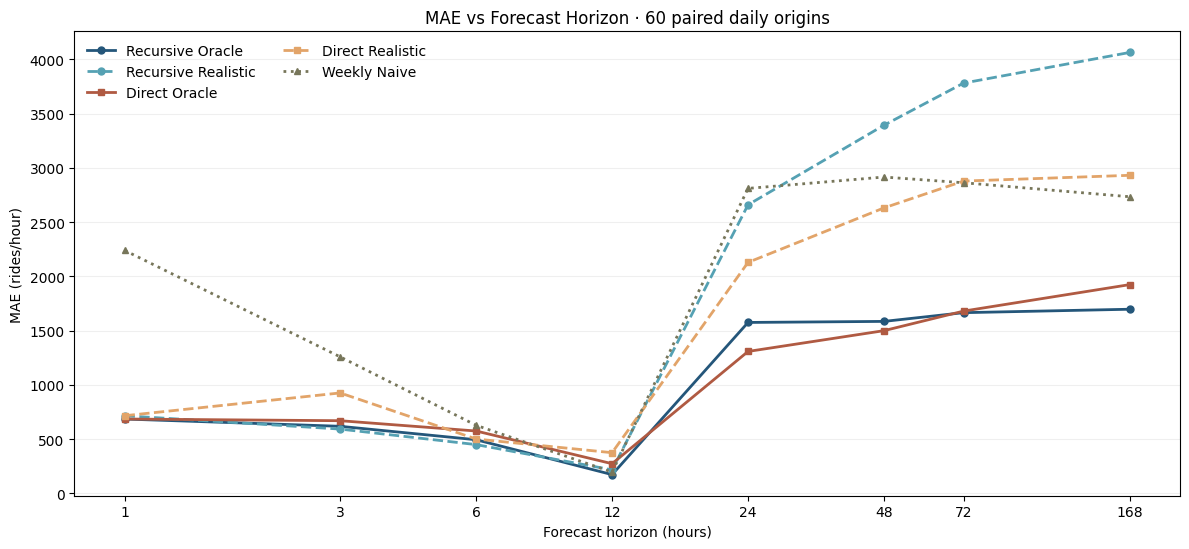

In [11]:
fig, ax = plt.subplots(figsize=(12, 5.6))
for column, linestyle, marker in (
    ("Recursive Oracle", "-", "o"),
    ("Recursive Realistic", "--", "o"),
    ("Direct Oracle", "-", "s"),
    ("Direct Realistic", "--", "s"),
    ("Weekly Naive", ":", "^"),
):
    ax.plot(
        core["Horizon"], mae_wide.loc[list(HORIZONS), column].to_numpy(),
        label=column, color=COLORS[column],
        linestyle=linestyle, marker=marker, linewidth=2, markersize=5,
    )
ax.set_xscale("log", base=2)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([str(h) for h in HORIZONS])
ax.set(
    title="MAE vs Forecast Horizon · 60 paired daily origins",
    xlabel="Forecast horizon (hours)",
    ylabel="MAE (rides/hour)",
)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

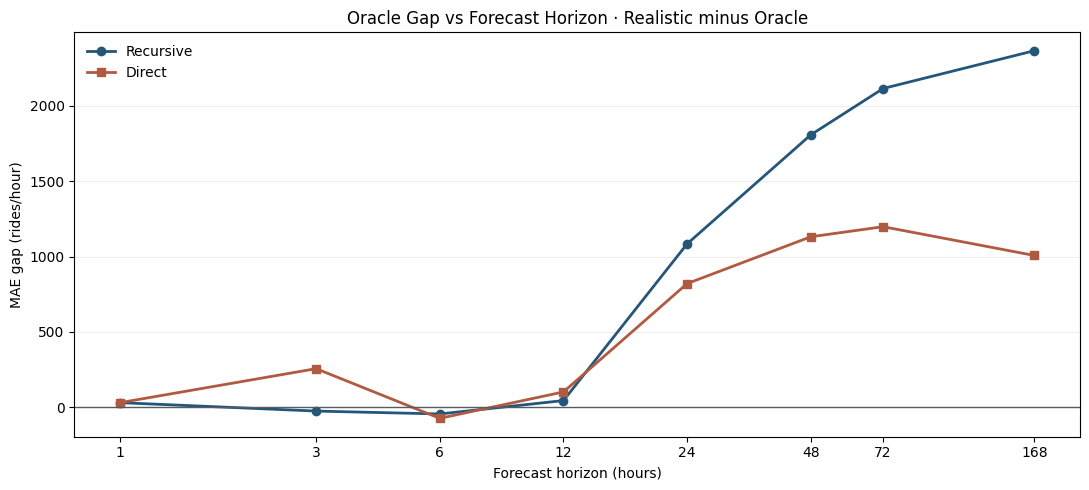

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
for method, marker in (("Recursive", "o"), ("Direct", "s")):
    ax.plot(
        core["Horizon"], core[f"{method} Oracle Gap"],
        label=method, marker=marker, linewidth=2,
        color=COLORS[f"{method} Oracle"],
    )
ax.axhline(0, color="#555B60", linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([str(h) for h in HORIZONS])
ax.set(
    title="Oracle Gap vs Forecast Horizon · Realistic minus Oracle",
    xlabel="Forecast horizon (hours)",
    ylabel="MAE gap (rides/hour)",
)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Peak-hour Analysis · 同一目标小时下比较天气影响

沿用 08 的共同 672 个目标小时，对 24/72/168h 分别调整起报时间。工作日早高峰 07–09（60 点）、晚高峰 16–19（80 点）逐点配对；另外增加工作日非高峰 340 点作为描述性对照。高峰和非高峰的需求强度不同，所以同时看绝对 Gap 与百分比 Gap。

In [13]:
peak_panels = {}
for horizon in PEAK_HORIZONS:
    first_future = peak_target_times - pd.Timedelta(hours=horizon - 1)
    frame = pd.DataFrame({
        "Horizon": horizon,
        "First Future Hour": first_future,
        "Forecast Origin": first_future - pd.Timedelta(hours=1),
        "Target Timestamp": peak_target_times,
        "Actual": observed_demand.reindex(peak_target_times).to_numpy(),
    })
    for scenario in ("oracle", "realistic"):
        label = scenario.title()
        frame[f"Recursive {label}"] = recursive_predict(
            first_future, horizon, scenario
        )[:, -1]
        frame[f"Direct {label}"] = models[scenario][horizon].predict(
            make_direct_matrix(scenario, first_future, peak_target_times)
        )
    assert len(frame) == 672
    assert np.isfinite(frame[["Actual"] + prediction_columns[:-1]].to_numpy()).all()
    assert frame["Target Timestamp"].equals(pd.Series(peak_target_times))
    peak_panels[horizon] = frame

peak_reference_08 = {
    (24, "Morning 07–09"): (1853.64, 1474.88),
    (24, "Evening 16–19"): (1450.00, 1534.83),
    (72, "Morning 07–09"): (2121.28, 1960.13),
    (72, "Evening 16–19"): (1547.03, 1979.29),
    (168, "Morning 07–09"): (2125.60, 1929.73),
    (168, "Evening 16–19"): (1553.90, 1827.58),
}
peak_rows = []
for horizon, frame in peak_panels.items():
    target = frame["Target Timestamp"]
    weekday = target.dt.dayofweek < 5
    morning = weekday & target.dt.hour.isin((7, 8, 9))
    evening = weekday & target.dt.hour.isin((16, 17, 18, 19))
    masks = {
        "Morning 07–09": morning,
        "Evening 16–19": evening,
        "Peak combined": morning | evening,
        "Weekday non-peak": weekday & ~(morning | evening),
    }
    expected_counts = {
        "Morning 07–09": 60, "Evening 16–19": 80,
        "Peak combined": 140, "Weekday non-peak": 340,
    }
    for period, mask in masks.items():
        subset = frame.loc[mask]
        assert len(subset) == expected_counts[period]
        row = {
            "Horizon": horizon, "Period": period, "Paired targets": len(subset),
        }
        for method in ("Recursive", "Direct"):
            for scenario in ("Oracle", "Realistic"):
                row[f"{method} {scenario} MAE"] = mean_absolute_error(
                    subset["Actual"], subset[f"{method} {scenario}"]
                )
            row[f"{method} Gap"] = (
                row[f"{method} Realistic MAE"] -
                row[f"{method} Oracle MAE"]
            )
            row[f"{method} Gap %"] = (
                100 * row[f"{method} Gap"] / row[f"{method} Oracle MAE"]
            )
        if (horizon, period) in peak_reference_08:
            recursive_08, direct_08 = peak_reference_08[(horizon, period)]
            assert abs(row["Recursive Oracle MAE"] - recursive_08) < 0.15
            assert abs(row["Direct Oracle MAE"] - direct_08) < 0.15
        peak_rows.append(row)
peak_table = pd.DataFrame(peak_rows)
display(peak_table.round(2))

,Horizon,Period,Paired targets,Recursive Oracle MAE,Recursive Realistic MAE,Recursive Gap,Recursive Gap %,Direct Oracle MAE,Direct Realistic MAE,Direct Gap,Direct Gap %
0,24,Morning 07–09,60,1853.64,1896.44,42.79,2.31,1474.88,1812.54,337.66,22.89
1,24,Evening 16–19,80,1450.00,2618.18,1168.18,80.56,1534.83,2229.16,694.33,45.24
2,24,Peak combined,140,1622.99,2308.86,685.87,42.26,1509.14,2050.61,541.47,35.88
3,24,Weekday non-peak,340,549.88,755.05,205.16,37.31,522.70,810.10,287.40,54.98
4,72,Morning 07–09,60,2121.28,2026.88,-94.40,-4.45,1960.13,2240.94,280.81,14.33
5,72,Evening 16–19,80,1547.03,3764.17,2217.14,143.32,1979.29,2966.98,987.68,49.90
6,72,Peak combined,140,1793.14,3019.62,1226.48,68.40,1971.08,2655.82,684.74,34.74
7,72,Weekday non-peak,340,660.80,1007.29,346.49,52.43,616.62,913.81,297.19,48.20
8,168,Morning 07–09,60,2125.60,1997.53,-128.07,-6.03,1929.73,2284.38,354.65,18.38
9,168,Evening 16–19,80,1553.90,3940.63,2386.74,153.60,1827.58,3119.23,1291.66,70.68


### 相同 672 目标小时的长 horizon 核对

主 benchmark 的不同 horizon 目标日期不同。这里固定同一批 672 个目标小时，仅把起报时间分别前移 24/72/168h，再计算整体 MAE 与 Oracle Gap。它帮助判断上述长期形态是否只是目标小时构成造成；这张辅助表不替代 60 点主表，也不与主表数值混用。

In [14]:
common_target_rows = []
for horizon, frame in peak_panels.items():
    row = {"Horizon": horizon, "Common target points": len(frame)}
    for method in ("Recursive", "Direct"):
        for scenario in ("Oracle", "Realistic"):
            row[f"{method} {scenario} MAE"] = mean_absolute_error(
                frame["Actual"], frame[f"{method} {scenario}"]
            )
        row[f"{method} Gap"] = (
            row[f"{method} Realistic MAE"] - row[f"{method} Oracle MAE"]
        )
        row[f"{method} Gap %"] = (
            100 * row[f"{method} Gap"] / row[f"{method} Oracle MAE"]
        )
    common_target_rows.append(row)
common_target_table = pd.DataFrame(common_target_rows)
assert common_target_table["Common target points"].eq(672).all()
display(common_target_table.round(2))

,Horizon,Common target points,Recursive Oracle MAE,Recursive Realistic MAE,Recursive Gap,Recursive Gap %,Direct Oracle MAE,Direct Realistic MAE,Direct Gap,Direct Gap %
0,24,672,770.59,1154.74,384.15,49.85,764.58,1027.41,262.82,34.37
1,72,672,924.29,1508.69,584.40,63.23,955.83,1338.01,382.18,39.98
2,168,672,934.93,1613.66,678.73,72.60,861.57,1402.54,540.97,62.79


### 高峰与工作日非高峰的百分比 Gap

本表把同一批 20 个工作日中的 140 个高峰目标小时与 340 个非高峰目标小时并列。每一格的 Oracle/Realistic 自身严格配对；高峰和非高峰彼此是不同目标小时，因此只作描述性敏感度比较，不能单凭此表声称天气的因果作用或统计显著性。

In [15]:
peak_vs_nonpeak = peak_table.loc[
    peak_table["Period"].isin(["Peak combined", "Weekday non-peak"]),
    [
        "Horizon", "Period", "Paired targets",
        "Recursive Gap", "Recursive Gap %",
        "Direct Gap", "Direct Gap %",
    ],
].copy()
display(peak_vs_nonpeak.round(2))

,Horizon,Period,Paired targets,Recursive Gap,Recursive Gap %,Direct Gap,Direct Gap %
2,24,Peak combined,140,685.87,42.26,541.47,35.88
3,24,Weekday non-peak,340,205.16,37.31,287.40,54.98
6,72,Peak combined,140,1226.48,68.40,684.74,34.74
7,72,Weekday non-peak,340,346.49,52.43,297.19,48.20
10,168,Peak combined,140,1308.96,72.76,890.08,47.56
11,168,Weekday non-peak,340,415.55,62.65,434.56,75.34


### 24/72/168h：Oracle 与 Realistic 的主样本对比

第三张图用主 benchmark 的 60 个严格配对点。颜色区分模型策略，浅色区分无未来天气；柱形从零开始，避免放大绝对 MAE 差异。高峰表是另一组 672 目标小时，不与这张图混合。

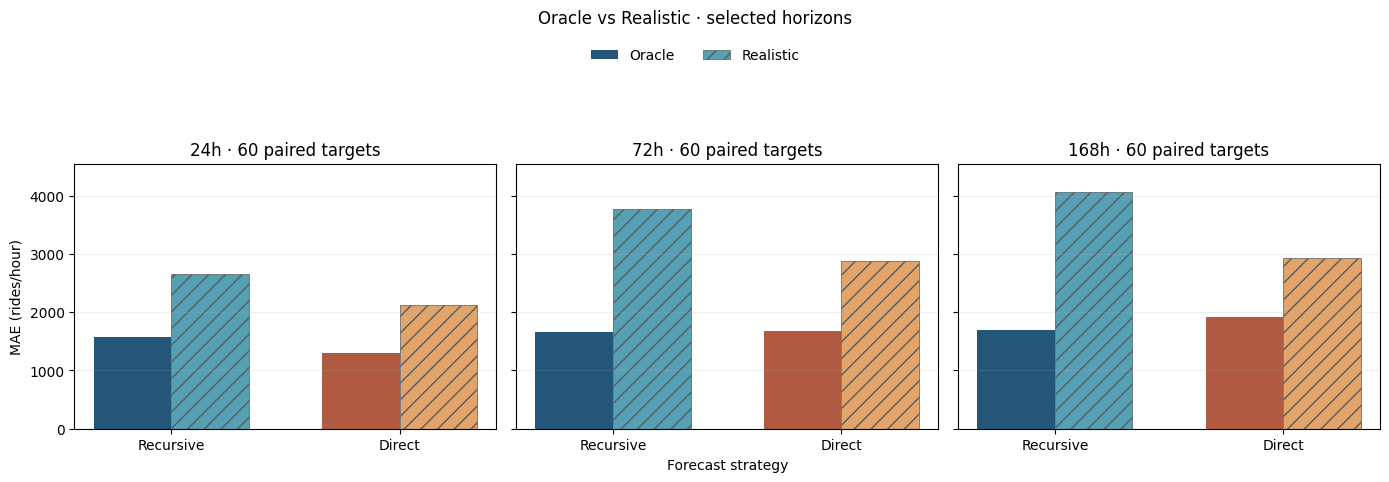

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
maximum_mae = core.loc[
    core["Horizon"].isin(PEAK_HORIZONS),
    [
        "Recursive Oracle MAE", "Recursive Realistic MAE",
        "Direct Oracle MAE", "Direct Realistic MAE",
    ],
].to_numpy().max()
for ax, horizon in zip(axes, PEAK_HORIZONS):
    row = core.loc[core["Horizon"].eq(horizon)].iloc[0]
    positions = np.arange(2)
    width = 0.34
    ax.bar(
        positions - width / 2,
        [row["Recursive Oracle MAE"], row["Direct Oracle MAE"]],
        width, label="Oracle", color=[
            COLORS["Recursive Oracle"], COLORS["Direct Oracle"]
        ],
    )
    ax.bar(
        positions + width / 2,
        [row["Recursive Realistic MAE"], row["Direct Realistic MAE"]],
        width, label="Realistic", color=[
            COLORS["Recursive Realistic"], COLORS["Direct Realistic"]
        ], hatch="//", edgecolor="#555B60", linewidth=0.5,
    )
    ax.set(
        title=f"{horizon}h · 60 paired targets",
        xticks=positions,
        xticklabels=["Recursive", "Direct"],
        ylim=(0, maximum_mae * 1.12),
    )
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("MAE (rides/hour)")
axes[1].set_xlabel("Forecast strategy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=2, loc="upper center",
           bbox_to_anchor=(0.5, 0.94))
fig.suptitle("Oracle vs Realistic · selected horizons", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

## Final Findings · 从配对结果回答部署问题

1. **未来真实天气会在中长期明显高估本样本的部署表现。** 主 benchmark 的 24h Oracle Gap 为 Recursive **+1,084.19（+68.84%）**、Direct **+820.66（+62.76%）** rides/hour；168h 分别为 **+2,366.31（+139.47%）**、**+1,007.20（+52.36%）**。这里的“明显”指误差幅度；本实验没有做正式统计显著性检验，不能将其表述为统计显著。
2. **Gap 并非全程随 horizon 单调增加。** 1h 两法均为 +30.27；3h/6h 有负 Gap，说明这几个特定目标钟点和样本上 Oracle 天气未必改善 MAE。24h 以后 Recursive Gap 从 **1,084 → 1,808 → 2,115 → 2,366**（24/48/72/168h）持续扩大；Direct 为 **821 → 1,131 → 1,198 → 1,007**，到 168h 回落。日频起点使短期 horizon 落在不同目标钟点，不能把跨 h 差异纯粹归因于提前量；24h 及以上均为 17:00 目标钟点，但目标日期仍不同。 固定同一批 672 个目标小时的辅助核对中，24/72/168h 的 Recursive Gap 为 384.15/584.40/678.73，Direct Gap 为 262.82/382.18/540.97，均随提前量增加。
3. **策略排名确实改变。** Oracle 下 3/6/12/72/168h 是 Recursive 较好，24/48h 是 Direct 较好，1h 持平。Realistic 下 3/6/12h 仍是 Recursive，**24/48/72/168h 变为 Direct**；72h、168h 发生反转。不过无天气 Direct 的 72h MAE **2,877.65** 与 Weekly Naive **2,862.25** 接近且略差；168h **2,930.74** 也差于 Weekly Naive **2,733.23**，因此“Direct 相对 Recursive 更好”不等于已达到有竞争力的长期部署基线。
4. **高峰对天气的依赖取决于误差尺度和策略。** 在共同目标小时样本上，24/72/168h 的工作日高峰合并组相对工作日非高峰组，**绝对** Gap 对两种策略都更大。按 Oracle MAE 归一化后，Recursive 高峰为 **42.26%/68.40%/72.76%**，非高峰为 **37.31%/52.43%/62.65%**；但 Direct 高峰为 **35.88%/34.74%/47.56%**，低于其非高峰 **54.98%/48.20%/75.34%**。晚高峰通常比早高峰更敏感；Recursive 的 72h/168h 早高峰 Gap 甚至为负。不能笼统说所有高峰都更依赖天气，高峰与非高峰也不是同一目标小时的因果对照。
5. **距离真实部署仍有条件缺口。** 本次 Realistic 场景完全不使用未来天气；实际部署可加入签发时可得的**天气预报值**，其线上性能理论上可能介于 No-weather 与 Oracle 两者之间，但不能保证。还需按预报发布时间与版本回放天气预报、验证需求结算延迟和缺失、在其他年份/季节及节假日与活动中检验漂移，并评估预测区间与运行成本。当前结果仅覆盖 2024 年这次固定切分。

**建议重点学习的代码 Cell：**“全样本 Leakage Audit”展示每个特征的来源与 Direct 标签；“Recursive”展示真实历史和预测回填的边界；“核心结果”展示同一目标点上如何计算 Oracle Gap 与策略排名；“Peak-hour Analysis”展示共同目标小时的配对分组。